In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1절. 분류분석 개요
    - 데이터 속성을 활용하여, 데이터에 대한 분류기준을 수립하는 과정 타겟변수가 categorical인 분석
        ex. 고객등급예측, 휴면고객예측, 상품구매예측, 보험사기자예측.....
    -sklearn패키지
    -pip install scikit-learn
## 라이브러리의 데이터셋의 접근(3가지 방법)
### load계열(패키지안에 데이터가 내장)   
    -load_iris(), load_boston()...

### fetch 계열(패키지에 데이터가 없고, 인터넷연결하여 다운로드)
    - fetch_covtype() : 토지조사 데이터
    - fetch_20newgroups() : 뉴스텍스트 말뭉치......

### make 계열(새로운 데이터 셋 생성)
    - make_classification(): 분류분석용 가상의 데이터 생성
    - make_regression(): 회귀분석용 가상의 데이터 생성
     seaborn / tensorflow / sklearn

In [5]:
# load계열(패키지내에 데이터가 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
#MNIST 데이터셋 로드
(X_train,y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape,y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


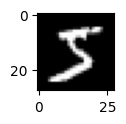

In [8]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0],cmap='gray')
plt.show()

In [ ]:
# fetch계열(인터넷 연결후 다운로드 c:/Users/내컴퓨터명/scikit_learn_data)

In [16]:
from sklearn.datasets import fetch_openml
import numpy as np
#MNIST데이터를 다운
mnist = fetch_openml(name='mnist_784',
                     version=1, #데이터 버전
                     as_frame=False, #False는 넘파이배열
                     parser='auto') # 파싱 방식을 sklearn이 자동결정

In [21]:
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46

In [31]:
X, y = mnist.data, mnist.target.astype(np.uint8) # y는 1byte짜리 양수int
X_reshaped=X.reshape(70000,28,-1)

In [27]:
X.shape, y.shape

((70000, 784), (70000,))

In [32]:
X_reshaped.shape

(70000, 28, 28)

In [34]:
X=X_reshaped

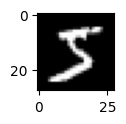

In [35]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0],cmap='gray')
plt.show()

# 2절. 분류분석의 종류

## 2.1 확률적 모형
- 주어진 데이터에 대해 각 클래스가 정답일 확률을 계산하는 모형
 - **predict_proba() : 각 분류 클래스가 될 확률들을 알려줌** (일부 판별함수모형에 있기는 함)
 - **predict_log_proba() : 확률의 로그값을알려줌**

### 1) 확률적 생성모형
- 각 클래스별 특징 데이터의 확률분포를 추정한 다음 베이즈 정리를 사용하여 확률 계산. 소량의 데이터로도 작동을 하는 경우
```
ex. sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis
    sklearn.naive_bayes.MultinomialNB

```

### 2) 확률적 판별모형
- 확률 함수를 추정하는 모형. 성능이 좋고, 해석이 쉬움
```
ex. sklearn.linear_model.LogisticRegression
    sklearn.tree.DecisionTreeClassifier(의사 결정나무) **분류에 영향을 주는 요인을 찾는데 더 많이 사용**
    
```

    
    
    
## 2.2 판별함수 모형
- 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후, 
  이 경계면으로 부터 데이터가 어느 위치에 있는 지 계산하는 판별함수를 이용하는 모형
 - **decision_function : 어떤 클래스로 분류되었는지를  알려줌**
 
```
ex. klearn.linear_model.Perceptron
    sklearn.svm.SVC
    sklearn.neural_network.MLPClassifier

```

=> RandomForest(배깅), XGboost, LGBM(부스팅), CatBoost등 앙상블 모형이 더 많이 사용됨

# 3절. 확률적 생성 모형
- 베이즈 정리를 사용한 확률분포 계산
## 3.1 QDA(QuadraticDiscriminantAnalysis)
- 독립변수 X가 실수이고, 정규분포라고 가정(pdf 11p)

In [75]:
#데이터 
from sklearn.datasets import make_classification  # 종속변수가 있는 data
X, y = make_classification(#n_samples=100, 데이터수(기본값)
                            n_features=2,    # 독립변수
                            n_informative=2, # 독립변수중 종속변수에 영향을 주는 변수 수
                            n_redundant=0,   # 독립변수끼리 선형관계가 있는 수(제외될 변수)
                            n_classes=2,     # 클래스 수
                            n_clusters_per_class=1, # 한 클래스당 군의 갯수
                            random_state=9,   # seed 값
                            weights=[0.5, 0.5]
)
X.shape, y.shape

((100, 2), (100,))

In [76]:
# y.mean() : 0과 1 클래스가 5:5 인지 확인
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [67]:
# y가 0인 독립변수 X
X[y==0][:3]

array([[-0.73358502,  0.37658657],
       [-2.25158719,  3.59851363],
       [-0.6615633 ,  0.60245197]])

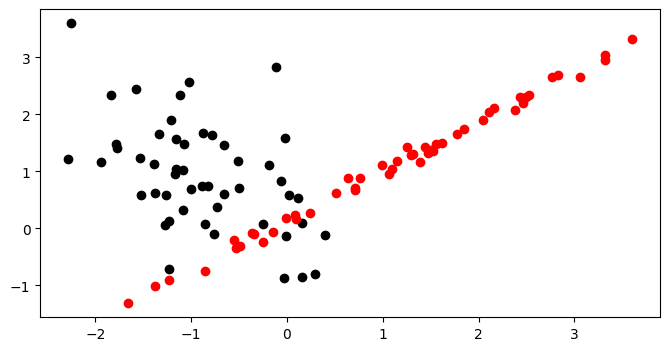

In [68]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (8,4)
plt.scatter(X[y==0,0],X[y==0,1], c='k')
plt.scatter(X[y==1,0],X[y==1,1], c='r')
plt.show()

In [131]:
# 대칭구조를 만듦
X[y==1] = -X[y==0]

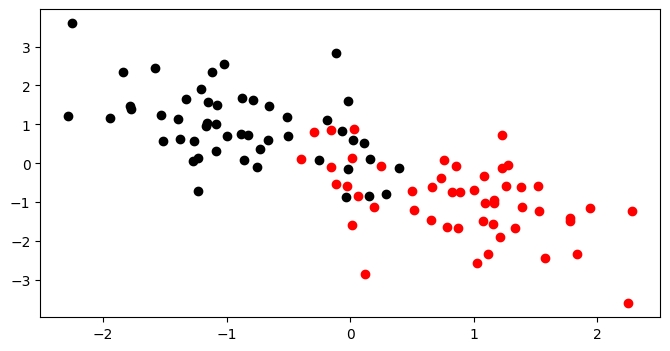

In [132]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (8,4)
plt.scatter(X[y==0,0],X[y==0,1], c='k')
plt.scatter(X[y==1,0],X[y==1,1], c='r')
plt.show()

In [133]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model =QuadraticDiscriminantAnalysis()
model.fit(X,y)

QuadraticDiscriminantAnalysis()

In [134]:
x = [[0,0]] # 입력데이터 2차원
p=model.predict_proba(x) #각 class가 될 확률
print(p) # 확률 2차원

[[0.5 0.5]]


In [116]:
model.predict(x)

array([1])

In [117]:
# 모델의 분류
model.classes_

array([0, 1])

In [122]:
# 교차표(혼동행렬)
import pandas as pd
y_hat=model.predict(X)
pd.crosstab(y,y_hat, colnames=['예측'],rownames=['실제'], margins=True)

예측,0,1,All
실제,,,
0,48,2,50
1,0,50,50
All,48,52,100


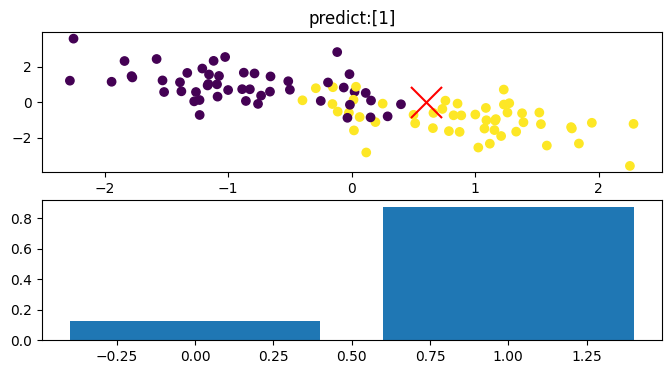

In [156]:
x = [[0.6,0]]
p =model.predict_proba(x)[0]
plt.subplot(211)#2행 1열로 subplot에서 첫번째 그래프
plt.scatter(x=X[:,0], y=X[:,1],c=y)
plt.scatter(x=x[0][0], y=x[0][1],c='r',marker='x',s=500)
h=model.predict(x)
plt.title(f'predict:{h}')
plt.subplot(212)
plt.bar(model.classes_,p)
plt.show()

## 3.2 나이브베이지안 모형
- MultinomialNB


In [158]:
import seaborn as sns
iris = sns.load_dataset('iris')
#학습데이터: 판다스 -> 넘파이배열

In [164]:
X=iris.iloc[:,:-1].values
y=iris.iloc[:,-1].values
# 모형 생성 및 학습
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X,y)

MultinomialNB()

In [166]:
x=[[5.1,3.5, 1.4,0.2]]
h = model.predict(x) # 예측값
p =model.predict_proba(x) # 각 클래스별 확률
print('예측:', h)
print(model.classes_)
print(p)

예측: ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75199536 0.16092948 0.08707516]]


<BarContainer object of 3 artists>

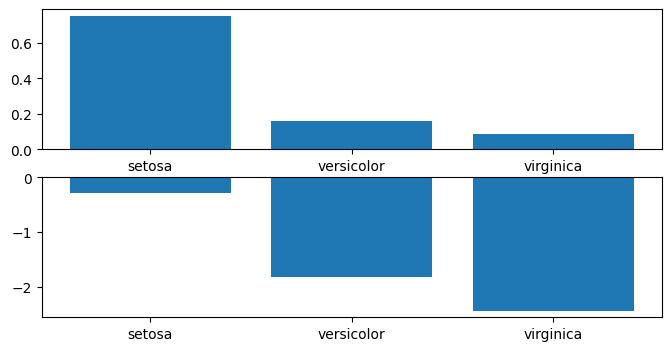

In [169]:
plt.subplot(211)
plt.bar(model.classes_, model.predict_proba(x)[0])
plt.subplot(212)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [170]:
model.score(X,y) # 모델의 정확도


0.9533333333333334

# 4절. 모형2 확률적 판별모형
## 4.1 로지스틱 회귀모형(이진분류)
- 종속변수가 0 또는 1 인경우  

In [173]:
# 가상의 데이터 셋
X, y = make_classification(n_samples=100, # 데이터 갯수(행수)
                           n_features=1, # 독립변수 갯수 (기본값20)
                           n_informative=1, #제외될 독립변수 갯수(기본값2)
                           n_redundant=0, # 종속변수에 영향을 주는 독립변수 갯수 (기본값2)
                           n_classes=2,   # 종속변수의 클래스 수
                           n_clusters_per_class=1, #클래스당 군의 갯수(기본값2)
                           random_state=1
                           )
X.shape , y.shape

((100, 1), (100,))

In [174]:
np.c_[X,y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [175]:
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [177]:
# 모형
from sklearn.linear_model import LogisticRegression
model=LogisticRegression().fit(X,y)

In [185]:
x_data= np.linspace(-3,3,100)
#2차원 데이터를 만들기 위한 축확장
#x_data=x_data.reshape(-1,1)
x_data = x_data[:,np.newaxis]
#np.expand_dims(x_data,axis=1)
prob= model.predict_proba(x_data) #-3부터 0일확률과 1일 확률 

In [191]:
prob0=prob[:,0] # 0일 확률들
prob1=prob[:,1] # 1일 확률들

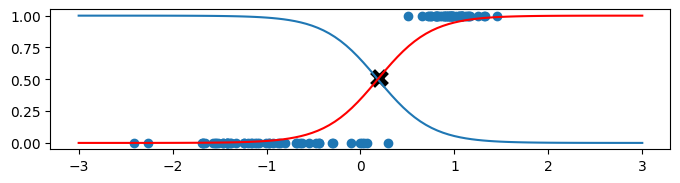

In [199]:
plt.subplot(2,1,1)
plt.scatter(X,y)
plt.plot(x_data,prob0)
plt.plot(x_data,prob1,c='r')
x=[[0.2]]
prob_x=model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5,s=100)
plt.show()

## 4.2 의사결정나무
- 여러가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 분류 모형
- 종속변수에 영향을 주는 독립변수의 범주를 찾는 목적

In [2]:
from sklearn.datasets import load_iris
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [18]:
X = data.data
X = X[:,2:]
y = data.target
feature_names = [name[:-5] for name in data.feature_names[2:4]]
X.shape, y.shape, feature_names

((150, 2), (150,), ['petal length', 'petal width'])

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt_model =DecisionTreeClassifier(criterion='entropy',  #트리의 분류품질기준을 entropy값으로  
                                max_depth=1,
                                random_state=0)
dt_model.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [12]:
#의사결정나무 분류모형의 시각화
import io
from sklearn.tree import export_graphviz # 모델을 그래프 생성 
import pydot                             # 생성된 그래프를 이미지로 변환
from IPython.core.display import Image   # 이미지를 브라우저에 출력

In [19]:
def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)

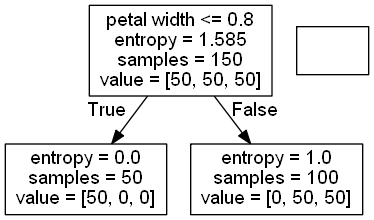

In [35]:
draw_decision_tree(dt_model, feature_names)

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
            np.arange(x2_min, x2_max, resolution))
    Z = model.predict(
        np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
            c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
    plt.xlabel(data.feature_names[2])
    plt.ylabel(data.feature_names[3])
    plt.legend(loc='upper left')
    plt.title(title)
    return Z


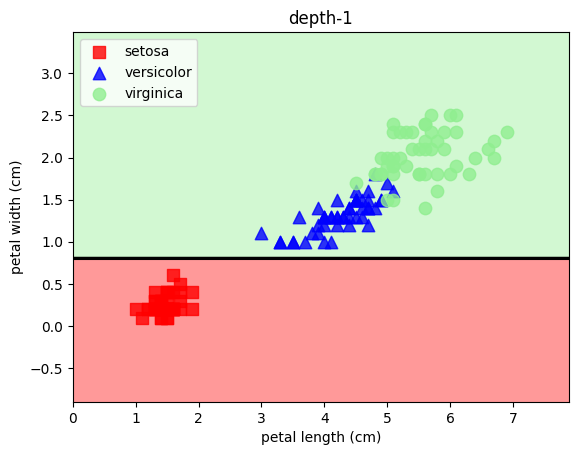

In [22]:
plot_decision_regions(X, y,dt_model,'depth-1')
plt.show()

In [23]:
x_data= [[6,2.5]]
dt_model.predict(x_data)

array([1])

In [24]:
print(dt_model.classes_)
dt_model.predict_proba(x_data)

[0 1 2]


array([[0. , 0.5, 0.5]])

In [7]:
print(dt_model.score(X,y))

0.6666666666666666


In [25]:
dt_model5=DecisionTreeClassifier(criterion='entropy',
                                max_depth=5, #최대 나무 깊이
                                random_state=0)
dt_model5.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

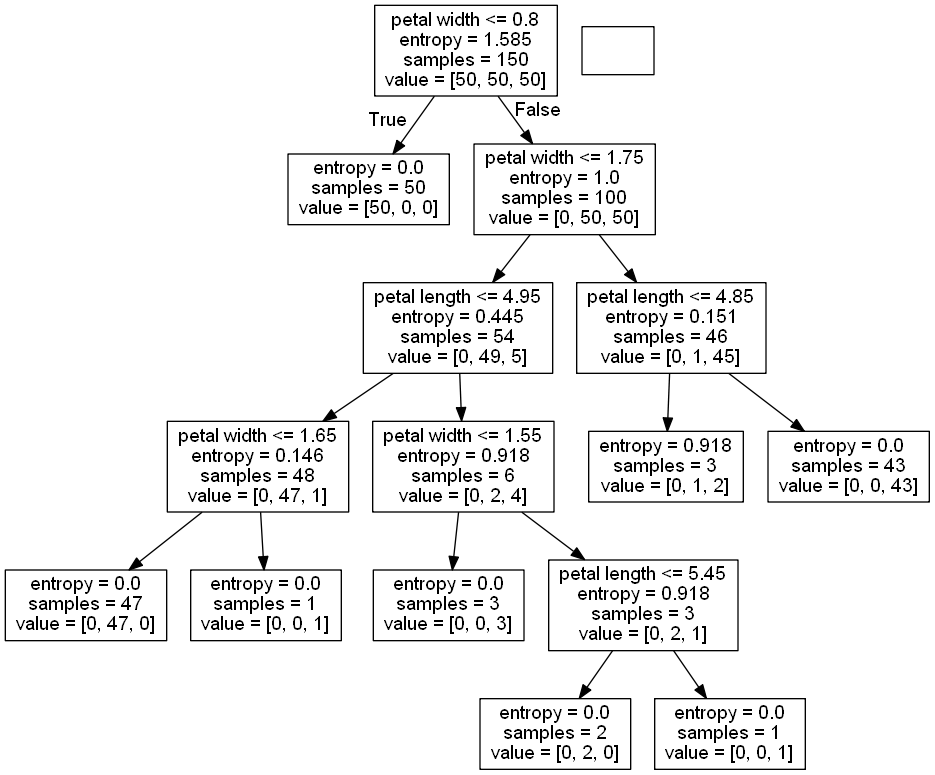

In [36]:
draw_decision_tree(dt_model5,feature_names)

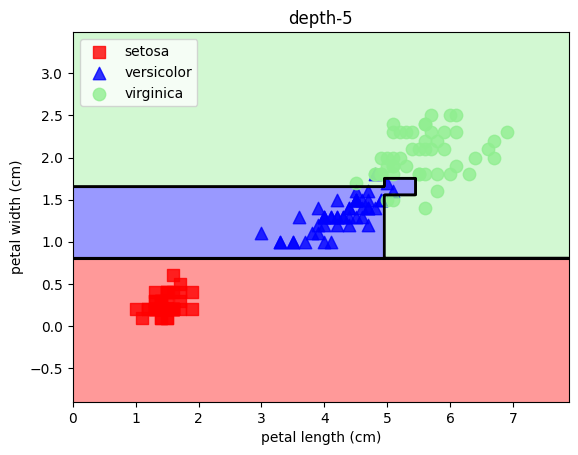

In [30]:
plot_decision_regions(X,y,dt_model5, 'depth-5')
plt.show()

In [9]:
dt_model5.score(X,y)

0.9933333333333333

In [10]:
dt_model5.predict(x_data)

array([2])

In [31]:
dt_model5.predict_proba(x_data)

array([[0., 0., 1.]])

# 5절. 모형3 - 판별함수 모형
- 동일한 클래스가 모여 있는 영역과 그외 영역을 나누는 경계면을 정의
- decision_function()함수를 제롱
- Percenptron, SVM, 다층인공신경망 모형등이 있음(일부의 모형에서는 predict_proba()가 제공됨)

## 5.1  Percenptron


In [40]:
from sklearn.datasets import load_iris
import numpy as np
iris=load_iris()
X= np.r_[iris.data[:50, 0:2],iris.data[100:, 0:2]] # 0~49 + 100~149번째만
y=np.r_[iris.target[:50],iris.target[100:]]
X.shape, y.shape

((100, 2), (100,))

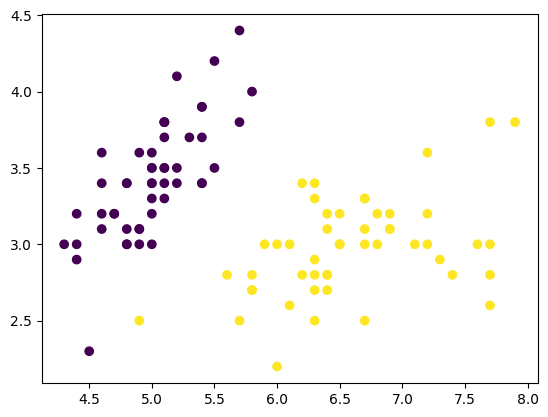

In [45]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1], c=y)

In [49]:
# 퍼셉트론 모형
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=100, # epoch 학습횟수
                   eta0=0.1,  #learning rate
                   random_state=1).fit(X,y)

In [54]:
import pandas as pd
y_pred =model.predict(X)
y_pred
pd.crosstab(y,y_pred, rownames=['true'], colnames=['pred'],margins=True)

pred,0,2,All
true,,,
0,49,1,50
2,0,50,50
All,49,51,100


In [55]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [60]:
#잘못 예측한 값 찾아보기
for idx, (real,pred) in enumerate(zip(y,y_pred)):
    if real != pred :
        print(f'{idx}번째 실제값 :{real}, 예측값 :{pred}- 데이터 : {X[idx]}')
    #print(idx,real, pred)

41번째 실제값 :0, 예측값 :2- 데이터 : [4.5 2.3]


In [62]:
x_data=[[4.5,2.3]]
print('예측:', model.predict(x_data))
print(model.decision_function(x_data))
# decision_function(x) 결과 양수 : 2
# decision_function(x) 결과 음수 : 0

예측: [2]
[1.24]


In [67]:
x_data = X[0][np.newaxis,:] #X[0].reshape(1,-1)
x_data
print('예측:', model.predict(x_data))
print(model.decision_function(x_data))

예측: [0]
[-3.134]


## 5.2 SVC 
- Support Vector Classifier

In [71]:
from sklearn.svm import SVC
model = SVC(
            probability=True
)
model.fit(X,y)

SVC(probability=True)

In [72]:
x_data=[[4.5,2.3]]
print('예측:', model.predict(x_data))
print(model.decision_function(x_data))
print(model.predict_proba(x_data))

예측: [0]
[-0.72539221]
[[0.89975106 0.10024894]]


## 5.3 다중퍼셉트론(다층 인공시경망)
- predict / predict_proba / decision_function 모두 가능


In [80]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(50,50,30),
                   max_iter = 500  #학습횟수 : 작으면 경고가 출력되기도 함
                   ) 
mlp.fit(X,y)

MLPClassifier(hidden_layer_sizes=(50, 50, 30), max_iter=500)

In [81]:
pred = mlp.predict(X)
pd.crosstab(y,pred)

col_0,0,2
row_0,,
0,49,1
2,0,50


# 6절. 분류모형 성능평가
## 6.1 sklearn-learn의 모형 평가 방법
- 예측 모형의 score메서드 
    * 예측모형의 score(test_X, test_y) 함수가 기본 제공(분류모형의 경우 accuracy, 회귀모형의 경우 r2 결정 계수
        군집분석은 score없음)
- metsrics 패키지 함수
    * accuracy, recall, precision, 특이도, 위양성율(fp rate), f-1score, f-beta score, ... roc 커브
- scoring 매개변수
    * GridSearchCV클래스를 이용한 교차검증 분석도구 => ch4.2
    
## 6.2 혼동행렬을 이용한 평가
- accuracy, recall, precision, 특이도, 위양성율(fp rate), f-1score, f-beta score

In [82]:
import pandas as pd
result =pd.read_csv('data/model_result.csv') #보험사기자 실제값과 예측값
result.head()

,CUST_ID,y_true,y_pred
0,37,0,0
1,51,0,0
2,60,0,0
3,65,0,0
4,73,0,0


In [84]:
result.isna().sum() # 결측치 갯수

CUST_ID    0
y_true     0
y_pred     0
dtype: int64

In [91]:
# 보험사기자 여부 0:1의 비율
print('전체 데이터수 :', result.shape[0])
print('N0:P1 비율:', result.y_true.value_counts())
print('N0:P1 빈도:', result.y_true.value_counts(normalize=True))

전체 데이터수 : 1793
N0:P1 비율: 0    1635
1     158
Name: y_true, dtype: int64
N0:P1 빈도: 0    0.91188
1    0.08812
Name: y_true, dtype: float64


In [89]:
# 혼동행렬
pd.crosstab(result.y_true, result.y_pred, margins=True)

y_pred,0,1,All
y_true,,,
0,1613,22,1635
1,81,77,158
All,1694,99,1793


In [90]:
# 혼동행렬
#FP가 높으면 고객의 불만이 높아짐, precision이 낮아짐
#  → FP를 낮추면 FN이 높아진다 회사의 cost가 증가 , recall도 떨어진다.

# 특이도 : TN/ (TN + FP)  TN/실제가 0인 경우

from sklearn.metrics import confusion_matrix
confusion_matrix(result.y_true, result.y_pred)

array([[1613,   22],
       [  81,   77]], dtype=int64)

In [93]:
# 이진분류에서의 accuracy, precision, recall
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve
print('정확도(accuracy):', accuracy_score(result.y_true, result.y_pred))
print('정밀도(precision):', precision_score(result.y_true, result.y_pred))
print('재현율(recall):', recall_score(result.y_true, result.y_pred))

정확도(accuracy): 0.9425543781372002
정밀도(precision): 0.7777777777777778
재현율(recall): 0.4873417721518987


In [94]:
# 다중분류에서의 precision, recall
# average : binary(기본값; 이진분류), 
#           macro(클래스별 샘플수를 가중치로 곱하여 평균계산),
#           weighted(클래스별 불균형이 심할 때의 평균계산)
#print('정밀도(precision):', precision_score(result.y_true, result.y_pred, average='macro'))
#print('재현율(recall):', recall_score(result.y_true, result.y_pred, average='macro'))

정밀도(precision): 0.8649809786173422
재현율(recall): 0.7369430573297719


In [97]:
#f1 score(precision과 recall의 조화평균)=2 * (precision*recall) / (precision + recall )  *트레이드오프 관계의 평균
from sklearn.metrics import f1_score, roc_curve, fbeta_score
print('f1 score :', f1_score(result.y_true, result.y_pred))

f1 score : 0.5992217898832685


In [101]:
#f beta score= (1 + beta제곱) * (precision*recall) / (beta제곱*precision + recall ) 

# precison의 가중치가 높음(고객의 만족도 우선) : beta가 1미만
print(fbeta_score(result.y_true, result.y_pred,beta=0.5))
# recall의 가중치가 높음(회사의 비용 중시) : beta가 1초과 
print(fbeta_score(result.y_true, result.y_pred,beta=1.5))
#precision과 recall의 가중치를 같게 : beta가 1 == f1_score
print(fbeta_score(result.y_true, result.y_pred,beta=1))

0.6949458483754513
0.5506050605060505
0.5992217898832685


In [106]:
# 특이도 : 0이라고 제대로 예측한 수 /실제 0인 수 
spec = recall_score(result.y_true, result.y_pred,pos_label=0)  #positive label =0 

In [109]:
# 위양성률(fp rate = 1종오류, 오탐) 
1- spec

0.013455657492354778

## 6.3 ROC 커브를 이용한 성능 비교 
- ROC커브 : 클래스의 판별 기준값의 변화에 따른 위양성률(fall-out;fp_rate)와 재현율(recall; tp_rate)
- 세로축 : tp_rate(재현율) 
- 가로축 : fp_rate(위양성율)

In [113]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, # 데이터 행수
                          n_features=2,  # 독립변수 갯수
                          n_informative=2, # 종속변수에 영향을 주는 독립변수 갯수
                          n_redundant=0,   # 제외될 독립변수 갯수
                          random_state=0,
                          n_classes=2
                          )
X.shape, y.shape

((100, 2), (100,))

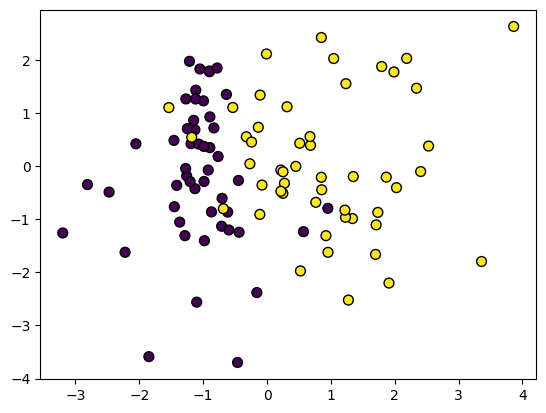

In [115]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1], c=y, edgecolors='k',s=50)
plt.show()

In [117]:
from sklearn.svm import SVC
model = SVC(probability=True)  #predict proba 사용하려면 true
model.fit(X,y)

SVC(probability=True)

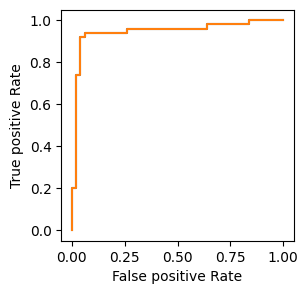

In [123]:
# roc_curve() 함수를 이용하여 fprate tprate 값을 도출
    # roc_curve(y), model.decision_function(X))
    # roc_curve(y), model.predict_proba(X)[:,1])
y_pred =model.predict(X)

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y,model.decision_function(X))

# model.predict_proba(X)[:,1] : 1로 예측될 확률
fpr1,tpr1, thresholds =roc_curve(y,model.predict_proba(X)[:,1])
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr)
plt.plot(fpr1, tpr1)
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.show()

## 6.4 두 모형의 혼동행렬이 같은 경우(roc_curve사용)

In [134]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,
                          weights=[0.95,0.05], #0이 95%, 1이 5%
                          n_classes=2,
                          random_state=5
                          )
X.shape, y.shape

((1000, 20), (1000,))

In [135]:
np.unique(y,return_counts=True)

(array([0, 1]), array([943,  57], dtype=int64))

In [136]:
from sklearn.linear_model import LogisticRegression
model1 =LogisticRegression().fit(X,y)

In [137]:
model2 = SVC(gamma=0.0001, #작을수록 결정경계의 곡률이 부드럽게 경계, 클수록 구불구불한 경계
             C=3000, #오차허용 수준 설정
             probability=True
            ).fit(X,y)

In [148]:
from sklearn.tree import DecisionTreeClassifier
model3 =DecisionTreeClassifier(random_state=42).fit(X,y)

In [149]:
# 두모델의 예측값
pred1 =model1.predict(X)
pred2 =model2.predict(X)
pred3 =model3.predict(X)

In [139]:
# 두 모델의 혼동행렬
confusion_matrix(y,pred1)

array([[940,   3],
       [ 30,  27]], dtype=int64)

In [140]:
# 두 모델의 혼동행렬
confusion_matrix(y,pred2)

array([[940,   3],
       [ 30,  27]], dtype=int64)

In [150]:
# 두 모델의 혼동행렬
confusion_matrix(y,pred3)

array([[943,   0],
       [  0,  57]], dtype=int64)

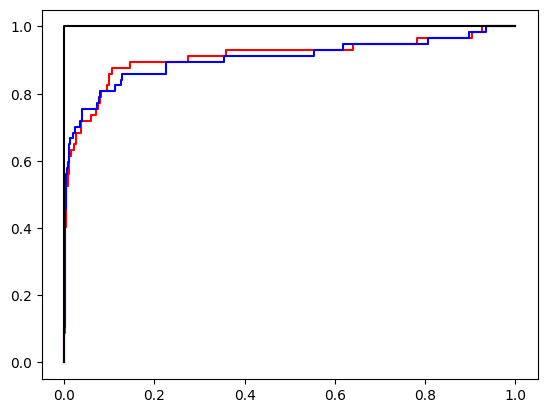

In [154]:
#roc curve
from sklearn.metrics import roc_curve
fpr1, tpr1, th1 = roc_curve(y, model1.predict_proba(X)[:,1])
fpr2, tpr2, th2 = roc_curve(y, model2.decision_function(X))
fpr3, tpr3, th3 = roc_curve(y, model3.predict_proba(X)[:,1])
plt.plot(fpr1, tpr1, c='r')
plt.plot(fpr2, tpr2, c='b')
plt.plot(fpr3, tpr3, c='k')
plt.show()

In [155]:
# AUC(Area Under Curve) : roc_curve 아래면적
from sklearn.metrics import auc
auc(fpr1,tpr1), auc(fpr2,tpr2), auc(fpr3,tpr3)

(0.9112202563673234, 0.9037227214377407, 1.0)